<a href="https://colab.research.google.com/github/Baasmaala/road-safety-explorer/blob/osama/notebooks/03_timeseries_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Data Acquisition
Cloning the road safety repository to access the dataset.

In [33]:
!git clone https://github.com/Baasmaala/road-safety-explorer.git

fatal: destination path 'road-safety-explorer' already exists and is not an empty directory.


### 2. Modular Forecasting Logic
Defining the functions for data loading, preparation, forecasting, and visualization.

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import os

def load_data(path):
    """Loads the dataset from the specified path."""
    return pd.read_csv(path)

def get_country_data(df, country_name=None):
    """
    Prepares data for Prophet. If country_name is provided, filters for it.
    Otherwise, aggregates deaths globally.
    """
    if country_name:
        subset = df[df['Entity'] == country_name].copy()
    else:
        subset = df.groupby('Year')['Deaths'].sum().reset_index()

    # Prophet format: ds (datestamp) and y (target)
    subset = subset.rename(columns={'Year': 'ds', 'Deaths': 'y'})
    subset['ds'] = pd.to_datetime(subset['ds'], format='%Y')
    return subset

def run_forecast(data, periods=10):
    """Fits Prophet and predicts future periods."""
    # Yearly data only, so we disable other seasonalities
    model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
    model.fit(data)
    future = model.make_future_dataframe(periods=periods, freq='YE')
    forecast = model.predict(future)
    return model, forecast

def plot_forecast(model, forecast):
    """Plots the Prophet forecast."""
    fig = model.plot(forecast)
    plt.xlabel('Year')
    plt.ylabel('Deaths')
    return fig

### 3. Deployment Export
Writing the functions to `forecast_utils.py` for Streamlit integration.

In [35]:
%%writefile forecast_utils.py
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

def load_data(path):
    return pd.read_csv(path)

def get_country_data(df, country_name=None):
    if country_name:
        subset = df[df['Entity'] == country_name].copy()
    else:
        subset = df.groupby('Year')['Deaths'].sum().reset_index()
    subset = subset.rename(columns={'Year': 'ds', 'Deaths': 'y'})
    subset['ds'] = pd.to_datetime(subset['ds'], format='%Y')
    return subset

def run_forecast(data, periods=10):
    model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
    model.fit(data)
    future = model.make_future_dataframe(periods=periods, freq='YE')
    forecast = model.predict(future)
    return model, forecast

def plot_forecast(model, forecast):
    fig = model.plot(forecast)
    return fig

Overwriting forecast_utils.py


In [36]:
from google.colab import files
files.download('forecast_utils.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Function Demonstration
Below we use the modular functions to run a forecast for India and visualize the results.

INFO:prophet:n_changepoints greater than number of observations. Using 23.


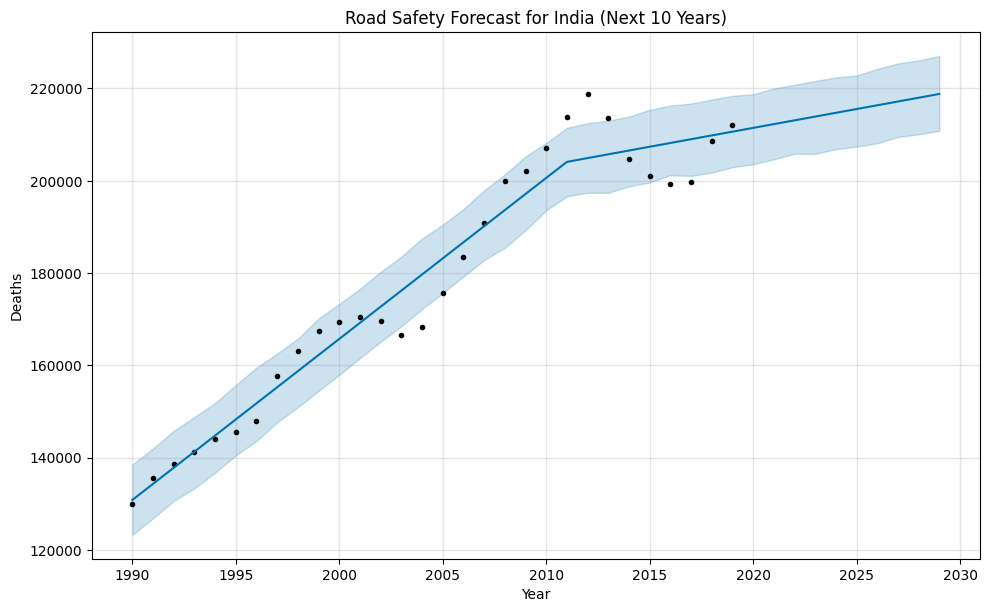

In [37]:
# 1. Define data path
path = '/content/road-safety-explorer/data/raw/output.csv'

# 2. Load the raw data
raw_data = load_data(path)

# 3. Prepare data for a specific country (e.g., India)
india_ts = get_country_data(raw_data, country_name='India')

# 4. Run the forecast model (default 10 years)
model, forecast = run_forecast(india_ts)

# 5. Visualize the results
fig = plot_forecast(model, forecast)
plt.title('Road Safety Forecast for India (Next 10 Years)')
plt.show()

### تحليل مكونات التوقع (Forecasting Components)
هنا بنشوف كيف الموديل بيفهم البيانات؛ هل الوفيات في ازدياد ولا نقصان؟ وكيف شكل الاتجاه العام (Trend) بعيداً عن التذبذبات السنوية.

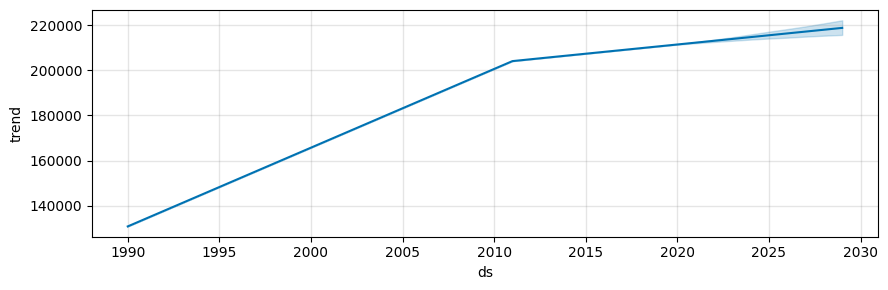

التوقعات الرقمية للسنوات القادمة (Forecasting Table):


,ds,yhat,yhat_lower,yhat_upper
30,2019-12-31,211443.809279,203560.065977,218748.280334
31,2020-12-31,212262.951654,204621.988610,219983.529620
32,2021-12-31,213079.855935,205828.378395,220793.518253
33,2022-12-31,213896.760216,205848.683860,221612.889180
34,2023-12-31,214713.664496,206819.934615,222400.933293
35,2024-12-31,215532.806871,207398.147926,222799.141876
36,2025-12-31,216349.711152,208128.695948,224235.148821
37,2026-12-31,217166.615433,209454.487681,225419.488398
38,2027-12-31,217983.519714,210054.584267,226062.033483
39,2028-12-31,218802.662089,210804.346637,227045.767966


In [39]:
# Visualize the components: Trend
fig2 = model.plot_components(forecast)
plt.show()

# عرض قيم التوقعات للسنة القادمة والأعوام التالية بالأرقام
print("التوقعات الرقمية للسنوات القادمة (Forecasting Table):")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))